# Market Basket Analysis — which products are bought together, and what to do about it

**Author:** Fordrane Albert Okumu · **Tools:** Python (pandas, mlxtend, networkx, scipy, matplotlib)
**Companion:** the same analysis rebuilt from scratch in base R lives in [`R/market_basket_analysis.R`](../R/market_basket_analysis.R).

---

## 0. Why this analysis matters

Every till receipt is a small record of customer intent. One receipt says little. Put **15,000 receipts** side by side, though, and patterns show up: *people who buy spaghetti very often also buy pasta sauce*. **Market Basket Analysis (MBA)** is the set of techniques for finding those patterns, measuring how strong they are, and turning them into commercial decisions.

### The business questions this notebook answers

| # | Question | Who uses the answer |
|---|---|---|
| 1 | Which products are bought **together** far more often than chance would predict? | Category & trade marketing |
| 2 | If a shopper has product **A** in the basket, what are they **likely to add next**? | E-commerce / POS recommendations |
| 3 | Which pairs make good **bundles** or **promotions**, and which promotions would be wasted? | Commercial & pricing |
| 4 | Should related products sit **next to each other** on the shelf? | Merchandising / planogram teams |
| 5 | Do **supermarket** and **duka** (neighbourhood shop) shoppers behave differently? | Sales / route-to-market |

### The data

The dataset is **synthetic**. It was generated by [`data/generate_transactions.py`](../data/generate_transactions.py) to look like a Kenyan FMCG retail network: 15,000 baskets, 44 products and 11 categories. Baskets are built from realistic shopping *missions* (tea time, dinner cook, BBQ, cleaning and so on), plus random impulse buys. No real company or customer data is used.

> **How to read this notebook:** every code cell is preceded by a *what & why* note and followed by an *interpretation* note.

## 1. Setup

We use:

* **pandas** for data wrangling
* **mlxtend** for the FP-Growth algorithm and association-rule generation (the standard Python library for this)
* **scipy** for significance tests on the rules
* **networkx** to draw the product network
* **matplotlib** for charts

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy.stats import fisher_exact
from mlxtend.frequent_patterns import fpgrowth, apriori, association_rules

ROOT = Path.cwd().parent if Path.cwd().name == "python" else Path.cwd()
OUT = ROOT / "outputs" / "python"
OUT.mkdir(parents=True, exist_ok=True)

TEAL, AMBER, GREY = "#0f766e", "#b45309", "#94a3b8"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titleweight": "bold", "font.size": 10})
pd.set_option("display.width", 160, "display.max_colwidth", 60)

## 2. Load the transactions

The raw data is in **long format**: one row per product per invoice. That's how POS and ERP systems usually export sales lines.

| column | meaning |
|---|---|
| `invoice_id` | the basket / receipt identifier, which is the unit of analysis in MBA |
| `date` | transaction date |
| `store_type` | `Supermarket` or `Duka` |
| `product`, `category` | what was bought |
| `quantity`, `unit_price_kes` | how many, and at what price |

In [2]:
tx = pd.read_csv(ROOT / "data" / "transactions.csv", parse_dates=["date"])
tx["line_value_kes"] = tx.quantity * tx.unit_price_kes
print(f"{tx.invoice_id.nunique():,} baskets | {len(tx):,} line items | {tx['product'].nunique()} products | "
      f"{tx.category.nunique()} categories | {tx.date.min():%d %b %Y} - {tx.date.max():%d %b %Y}")
tx.head(8)

15,000 baskets | 67,045 line items | 44 products | 11 categories | 01 Jan 2026 - 30 Jun 2026


,invoice_id,date,store_type,product,category,quantity,unit_price_kes,line_value_kes
0,INV000000,2026-06-01,Duka,Beef Sausages 500g,Deli & Meat,1,420,420
1,INV000000,2026-06-01,Duka,Smoked Bacon 250g,Deli & Meat,1,480,480
2,INV000001,2026-03-09,Duka,Brown Bread 400g,Bakery,1,70,70
3,INV000001,2026-03-09,Duka,Bottled Water 1L,Beverages,3,80,240
4,INV000001,2026-03-09,Duka,Potato Crisps 150g,Snacks,1,150,150
5,INV000001,2026-03-09,Duka,Salted Peanuts 200g,Snacks,3,130,390
6,INV000002,2026-05-25,Duka,Queen Cakes 6pk,Bakery,1,150,150
7,INV000002,2026-05-25,Duka,Breakfast Cereal 500g,Breakfast,2,520,1040


## 3. Data-quality checks

Rule mining is very sensitive to dirty data. A product recorded under two different names would split its true frequency in half, and duplicate lines would inflate co-occurrence. Before mining we check:

1. missing values
2. duplicate product lines inside the same basket
3. non-positive quantities or prices, such as returns or voids, which should be removed from a *purchase* analysis

In [3]:
checks = {
    "missing values": int(tx.isna().sum().sum()),
    "duplicate (invoice, product) lines": int(tx.duplicated(["invoice_id", "product"]).sum()),
    "quantity <= 0": int((tx.quantity <= 0).sum()),
    "price <= 0": int((tx.unit_price_kes <= 0).sum()),
}
pd.Series(checks, name="count").to_frame()

,count
missing values,0
"duplicate (invoice, product) lines",0
quantity <= 0,0
price <= 0,0


**Interpretation:** all checks pass with zero issues, so we can mine the data as it is. On real POS data you'd usually first remove returns and voids, merge duplicate SKUs, and decide whether to analyse at **SKU** level (e.g. *Fresh Milk 500ml*) or **category** level (e.g. *Dairy*). Category level gives fewer, broader rules. SKU level gives more actionable ones.

## 4. Exploratory analysis — understand the baskets before mining them

Two things decide what thresholds make sense later:

* **Basket size:** if most baskets hold only 1–2 items, rules involving 3+ items will be rare.
* **Item popularity:** very popular items (bread, milk) appear in many rules simply because they are everywhere. We need metrics that correct for that (see *lift* in section 6).

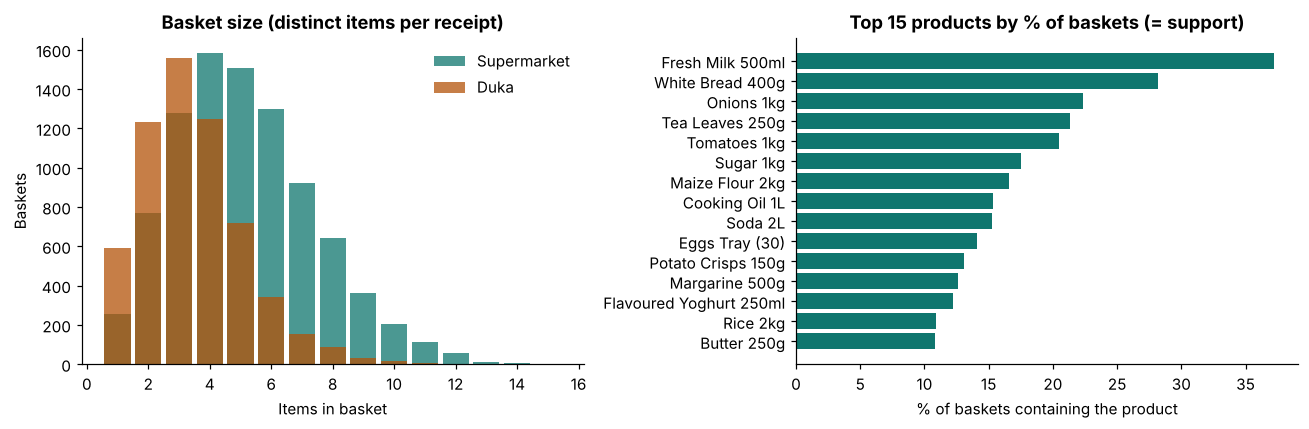

,baskets,avg_items,median_items,avg_value_kes
store_type,,,,
Duka,5984,3.4,3.0,1173.8
Supermarket,9016,5.1,5.0,2160.5


In [4]:
basket = tx.groupby("invoice_id").agg(items=("product", "nunique"), value=("line_value_kes", "sum"),
                                       store_type=("store_type", "first"))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for st, c in [("Supermarket", TEAL), ("Duka", AMBER)]:
    axes[0].hist(basket.loc[basket.store_type == st, "items"], bins=range(1, 17), alpha=.75,
                 color=c, label=st, align="left", rwidth=.85)
axes[0].set(title="Basket size (distinct items per receipt)", xlabel="Items in basket", ylabel="Baskets")
axes[0].legend(frameon=False)

item_share = (tx.groupby("product").invoice_id.nunique() / tx.invoice_id.nunique()).sort_values()
axes[1].barh(item_share.index[-15:], item_share.values[-15:] * 100, color=TEAL)
axes[1].set(title="Top 15 products by % of baskets (= support)", xlabel="% of baskets containing the product")
fig.tight_layout(); fig.savefig(OUT / "01_eda.png", dpi=150); plt.show()

basket.groupby("store_type").agg(baskets=("items", "size"), avg_items=("items", "mean"),
                                 median_items=("items", "median"), avg_value_kes=("value", "mean")).round(1)

**Interpretation:**

* The average basket has about **4.5 distinct items**. Supermarket baskets are clearly larger than duka baskets, which are mostly quick top-ups. That's enough items to find 2- and 3-item patterns.
* **Fresh milk** is in about **37%** of all baskets and **white bread** in about **28%**. Because they're everywhere, they'll show up in many rules with high *confidence* that don't really mean much. This is why we lean on **lift** rather than confidence alone.
* The long tail (mozzarella, baby wipes, BBQ sauce, cones, fresh cream, instant coffee) appears in only about 1.5–3.5% of baskets. These are often the most *interesting* associations, so our minimum-support threshold must be low enough to keep them.

## 5. Reshape into a basket × product matrix (one-hot encoding)

Association-rule algorithms need a **binary transaction matrix**: one row per basket, one column per product, and `True` if the product is in the basket. Quantity is ignored on purpose. MBA asks *whether* items are bought together, not *how many*.

In [5]:
X = pd.crosstab(tx.invoice_id, tx["product"]).gt(0)
print(f"Matrix shape: {X.shape[0]:,} baskets x {X.shape[1]} products  |  "
      f"density = {X.values.mean():.1%} of cells are True")
X.iloc[:5, :8]

Matrix shape: 15,000 baskets x 44 products  |  density = 10.2% of cells are True


product,BBQ Sauce 375ml,Baby Wipes,Bar Soap 800g,Beef Sausages 500g,Bottled Water 1L,Breakfast Cereal 500g,Brown Bread 400g,Burger Buns 6pk
invoice_id,,,,,,,,
INV000000,False,False,False,True,False,False,False,False
INV000001,False,False,False,False,True,False,True,False
INV000002,False,False,False,False,False,True,False,False
INV000003,False,False,False,False,False,False,False,False
INV000004,False,False,False,False,True,False,False,False


**Interpretation:** only about 10% of cells are `True`, because each basket holds a handful of the 44 products. The matrix is **sparse**, which is typical of retail data. Efficient algorithms like FP-Growth are designed to cope with this.

## 6. The four core metrics, worked out by hand

Before running any algorithm, it's worth computing the metrics manually for one familiar rule, **{Spaghetti} → {Pasta Sauce}**, so every number later is easy to read.

For a rule **A → B** (*"if A is in the basket, then B"*):

| Metric | Formula | Plain-English meaning | Rule of thumb |
|---|---|---|---|
| **Support** | P(A ∩ B) | Share of *all* baskets that contain both A and B | Is the pattern common enough to matter? |
| **Confidence** | P(B \| A) = support(A∩B) / support(A) | Of the baskets with A, the share that also have B | How reliable is "A suggests B"? |
| **Lift** | confidence / support(B) | How many times more likely B is when A is present, compared with B's normal rate | **>1** positive association, **=1** independent, **<1** substitutes / negative |
| **Leverage** | support(A∩B) − support(A)·support(B) | Extra share of baskets with both A and B, beyond what chance would give | >0 means more co-occurrence than chance |
| **Conviction** | (1 − supp(B)) / (1 − conf) | How much more often the rule would be *wrong* if A and B were independent | 1 = independent; high = strong rule |

In [6]:
A, B = "Spaghetti 500g", "Pasta Sauce 400g"
n = len(X)
n_A, n_B, n_AB = X[A].sum(), X[B].sum(), (X[A] & X[B]).sum()
supp_A, supp_B, supp_AB = n_A / n, n_B / n, n_AB / n
conf = supp_AB / supp_A
lift = conf / supp_B
leverage = supp_AB - supp_A * supp_B
conviction = (1 - supp_B) / (1 - conf)

pd.DataFrame({
    "value": [n_A, n_B, n_AB, supp_A, supp_B, supp_AB, conf, lift, leverage, conviction],
}, index=["baskets with Spaghetti", "baskets with Pasta Sauce", "baskets with both",
          "support(Spaghetti)", "support(Pasta Sauce)", "support(both)",
          "confidence  Spaghetti -> Sauce", "lift", "leverage", "conviction"]).round(4)

,value
baskets with Spaghetti,1113.0000
baskets with Pasta Sauce,773.0000
baskets with both,595.0000
support(Spaghetti),0.0742
support(Pasta Sauce),0.0515
support(both),0.0397
confidence Spaghetti -> Sauce,0.5346
lift,10.3737
leverage,0.0358
conviction,2.0379


**How to read these numbers:**

* **Support:** about 4% of all baskets contain *both* spaghetti and pasta sauce. That's around 600 receipts out of 15,000, so the pattern is common enough to act on.
* **Confidence:** a bit over half of spaghetti buyers also pick up pasta sauce. Put the other way, **the rest leave without sauce.** That's the cross-sell gap a recommendation or shelf placement would target.
* **Lift ≈ 10:** a shopper who has spaghetti is about **10 times** more likely to buy pasta sauce than an average shopper. This is very strong. In real retail data, lifts of 2–3 already count as meaningful.
* **Leverage > 0** and **conviction > 1** both confirm that this is more co-occurrence than chance would produce.

Lift is symmetric (A→B and B→A have the same lift), but **confidence is not**. Pasta Sauce → Spaghetti has much higher confidence, because almost everyone who buys sauce buys pasta, while plenty of people buy pasta without sauce. This asymmetry tells you which product should **trigger** the recommendation.

## 7. Find frequent itemsets with FP-Growth

Checking every possible combination of 44 products is impossible: there are 2⁴⁴ ≈ 17 trillion subsets. Two classic algorithms make it tractable:

* **Apriori** builds itemsets level by level, using one rule: *if an itemset is rare, every superset of it is rare too.* That lets it prune most combinations early.
* **FP-Growth** compresses the transactions into a prefix tree (FP-tree) and mines it without generating candidate itemsets. It returns **exactly the same itemsets** but is usually much faster on large data.

We use FP-Growth and check that Apriori gives the identical answer.

### Choosing `min_support`

This is the most important tuning choice:

* **Too high** (say 5%) and you only see the obvious bread-and-milk patterns, missing niche but profitable pairs like bacon and eggs.
* **Too low** (say 0.1%) and you get thousands of rules built on a handful of baskets, mostly noise.

We use **1%**, meaning an itemset must appear in at least **150 baskets**. That's enough evidence to trust and enough volume to justify a commercial action.

In [7]:
MIN_SUPPORT = 0.01
itemsets = fpgrowth(X, min_support=MIN_SUPPORT, use_colnames=True)
itemsets["size"] = itemsets.itemsets.map(len)

check = apriori(X, min_support=MIN_SUPPORT, use_colnames=True)
assert set(map(frozenset, check.itemsets)) == set(map(frozenset, itemsets.itemsets)), "FP-Growth != Apriori"
print(f"{len(itemsets)} frequent itemsets (Apriori result identical) - by size:")
print(itemsets["size"].value_counts().sort_index().to_string())

(itemsets[itemsets["size"] >= 2].sort_values("support", ascending=False).head(10)
 .assign(itemsets=lambda d: d.itemsets.map(lambda s: " + ".join(sorted(s))),
         baskets=lambda d: (d.support * n).round().astype(int)))

536 frequent itemsets (Apriori result identical) - by size:
size
1     44
2    296
3    165
4     29
5      2


,support,itemsets,size,baskets
448,0.171267,Fresh Milk 500ml + White Bread 400g,2,2569
433,0.169067,Fresh Milk 500ml + Tea Leaves 250g,2,2536
364,0.131133,Fresh Milk 500ml + Sugar 1kg,2,1967
245,0.128200,Onions 1kg + Tomatoes 1kg,2,1923
365,0.108067,Sugar 1kg + Tea Leaves 250g,2,1621
434,0.103733,Tea Leaves 250g + White Bread 400g,2,1556
257,0.097467,Maize Flour 2kg + Onions 1kg,2,1462
258,0.094600,Maize Flour 2kg + Tomatoes 1kg,2,1419
278,0.094533,Cooking Oil 1L + Onions 1kg,2,1418
369,0.092533,Fresh Milk 500ml + Sugar 1kg + Tea Leaves 250g,3,1388


**Interpretation:**

* Hundreds of product combinations pass the 1% bar. Most are pairs, a good number are triples, and only a few reach 4–5 items. This matches the basket-size profile from section 4.
* The most *frequent* pairs (milk + bread, milk + tea, milk + sugar, tea + sugar) describe the everyday **tea-time / "chai" mission** that dominates Kenyan baskets. **Onions + tomatoes** and **maize flour + onions** come next: that's the **dinner-cook** mission.
* Frequency alone doesn't make a pair interesting, though. Milk is in so many baskets that it pairs with almost everything. The next step turns itemsets into **rules** and ranks them by **lift**.

## 8. Generate association rules and filter them

From every frequent itemset we generate all **A → B** splits and keep the rules that are both **reliable** and **better than chance**:

* `confidence ≥ 0.30`: at least 30% of baskets with A also contain B
* `lift ≥ 1.2`: B is at least 20% more likely when A is present

We also add **Zhang's metric**, which runs from −1 to +1 and shows association (+) versus dissociation (−) on a bounded scale.

In [8]:
MIN_CONF, MIN_LIFT = 0.30, 1.2
rules = association_rules(itemsets, metric="lift", min_threshold=1.0)
rules = rules[(rules.confidence >= MIN_CONF) & (rules.lift >= MIN_LIFT)].copy()

fmt = lambda s: " + ".join(sorted(s))
rules["rule"] = rules.antecedents.map(fmt) + "  ->  " + rules.consequents.map(fmt)
rules["n_antecedent"] = rules.antecedents.map(len)
rules["n_consequent"] = rules.consequents.map(len)
rules["baskets"] = (rules.support * n).round().astype(int)
cols = ["rule", "baskets", "support", "confidence", "lift", "leverage", "conviction", "zhangs_metric"]
print(f"{len(rules)} rules pass confidence >= {MIN_CONF} and lift >= {MIN_LIFT}")
rules.sort_values("lift", ascending=False)[cols].head(15).round(3)

643 rules pass confidence >= 0.3 and lift >= 1.2


,rule,baskets,support,confidence,lift,leverage,conviction,zhangs_metric
1475,Baby Wipes -> Diapers 40pk,359,0.024,0.740,15.045,0.022,3.660,0.965
1474,Diapers 40pk -> Baby Wipes,359,0.024,0.486,15.045,0.022,1.884,0.982
1178,Mozzarella 200g + Spaghetti 500g -> Pasta Sauce 400g,206,0.014,0.701,13.597,0.013,3.169,0.945
1299,Cheddar Cheese 200g + Spaghetti 500g -> Pasta Sauce 400g,178,0.012,0.645,12.515,0.011,2.671,0.937
1478,Ice Cream 1L -> Ice Cream Cones,279,0.019,0.324,12.368,0.017,1.441,0.975
1479,Ice Cream Cones -> Ice Cream 1L,279,0.019,0.710,12.368,0.017,3.249,0.944
1176,Mozzarella 200g + Pasta Sauce 400g -> Spaghetti 500g,206,0.014,0.880,11.864,0.013,7.737,0.930
1298,Cheddar Cheese 200g + Pasta Sauce 400g -> Spaghetti 500g,178,0.012,0.873,11.759,0.011,7.264,0.928
33,Smoked Bacon 250g -> Beef Sausages 500g + Eggs Tray (30),227,0.015,0.308,11.521,0.014,1.406,0.960
32,Beef Sausages 500g + Eggs Tray (30) -> Smoked Bacon 250g,227,0.015,0.566,11.521,0.014,2.191,0.938


**Interpretation of the strongest rules (sorted by lift):**

* **Diapers ↔ Baby wipes** have the highest lift. That's a classic *complementary need*: same shopper, same mission. Shelving them together and bundling them is low-risk.
* **{Spaghetti + cheese} → Pasta Sauce** with lift > 12 shows a full **"pasta night" meal solution**. For a dairy manufacturer, this is a strong argument for co-promoting cheese with pasta brands, or for a recipe-led display.
* **Ice cream cones → Ice cream** has high confidence, but the reverse rule has much lower confidence. Cones are bought *because of* ice cream, not the other way round. So cones should sit next to the ice-cream freezer, and the cross-sell prompt should run *from* ice cream *to* cones.
* **{Sausages + Eggs} → Bacon** and the BBQ cluster (sausages, wings, buns, BBQ sauce, soda) show distinct **weekend fry-up** and **party** missions.

Rules with **2+ items on the left** are usually the most actionable for recommendation engines, because they use more of what the shopper already has in the basket.

## 9. Are the rules statistically real? Fisher's exact test with Bonferroni correction

With hundreds of rules, some will look strong just by chance. For each rule we build the 2×2 contingency table (A present/absent × B present/absent) and run a **one-sided Fisher's exact test** of whether A and B co-occur more than independence would predict.

Because we test many rules at once, we apply a **Bonferroni correction**: a rule is significant only if `p < 0.05 / number_of_rules`. This step is often skipped in MBA write-ups, but it separates real patterns from noise.

In [9]:
def fisher_p(row):
    a_mask = X[list(row.antecedents)].all(axis=1)
    b_mask = X[list(row.consequents)].all(axis=1)
    table = [[(a_mask & b_mask).sum(), (a_mask & ~b_mask).sum()],
             [(~a_mask & b_mask).sum(), (~a_mask & ~b_mask).sum()]]
    return fisher_exact(table, alternative="greater")[1]

rules["p_value"] = rules.apply(fisher_p, axis=1)
alpha = 0.05 / len(rules)
rules["significant"] = rules.p_value < alpha
print(f"Bonferroni threshold: p < {alpha:.2e}")
print(f"Significant rules: {rules.significant.sum()} of {len(rules)}")
rules.sort_values("p_value")[["rule", "lift", "p_value", "significant"]].tail(5)

Bonferroni threshold: p < 7.78e-05
Significant rules: 642 of 643


,rule,lift,p_value,significant
220,Breakfast Cereal 500g + Long-life Milk 1L -> Fresh Mil...,1.240380,0.000004,True
1330,Flavoured Yoghurt 250ml + White Bread 400g -> Fresh Mi...,1.232009,0.000011,True
1119,Fresh Milk 500ml + Long-life Milk 1L -> White Bread 400g,1.305775,0.000012,True
111,Brown Bread 400g + Butter 250g -> Fresh Milk 500ml,1.243444,0.000021,True
214,Breakfast Cereal 500g + Natural Yoghurt 500ml -> Fresh...,1.211797,0.000766,False


**Interpretation:** because we require at least 150 supporting baskets and a lift ≥ 1.2, almost every rule survives even this strict correction. The *weakest* rules (bottom of the table) are the ones to treat with caution. On real data with lower support thresholds, this step can remove a large share of rules, so it should always be run before handing rules to a commercial team.

## 10. Remove redundant rules

If **{Spaghetti} → {Sauce}** has confidence 0.53, then a longer rule like **{Spaghetti, Onions} → {Sauce}** is only worth keeping if it adds clearly more confidence. Otherwise it just repeats the shorter rule. Here we keep a longer rule only if its confidence is at least **10% higher** than that of every shorter rule with the same consequent whose antecedent it contains. The result is a shorter list that's easier to act on.

In [10]:
def prune_redundant(r, min_gain=1.10):
    keep = []
    by_cons = {}
    for idx, row in r.sort_values("n_antecedent").iterrows():
        subs = [c for a, c in by_cons.get(row.consequents, []) if a < row.antecedents]
        if not subs or row.confidence >= min_gain * max(subs):
            keep.append(idx)
        by_cons.setdefault(row.consequents, []).append((row.antecedents, row.confidence))
    return r.loc[keep]

strong = prune_redundant(rules[rules.significant & (rules.n_consequent == 1)])
print(f"{len(rules)} rules -> {len(strong)} non-redundant, significant, single-consequent rules")
strong.to_csv(OUT / "association_rules.csv", index=False,
              columns=cols + ["p_value"])
strong.sort_values("lift", ascending=False)[cols].head(12).round(3)

643 rules -> 249 non-redundant, significant, single-consequent rules


,rule,baskets,support,confidence,lift,leverage,conviction,zhangs_metric
1475,Baby Wipes -> Diapers 40pk,359,0.024,0.740,15.045,0.022,3.660,0.965
1474,Diapers 40pk -> Baby Wipes,359,0.024,0.486,15.045,0.022,1.884,0.982
1178,Mozzarella 200g + Spaghetti 500g -> Pasta Sauce 400g,206,0.014,0.701,13.597,0.013,3.169,0.945
1299,Cheddar Cheese 200g + Spaghetti 500g -> Pasta Sauce 400g,178,0.012,0.645,12.515,0.011,2.671,0.937
1478,Ice Cream 1L -> Ice Cream Cones,279,0.019,0.324,12.368,0.017,1.441,0.975
1479,Ice Cream Cones -> Ice Cream 1L,279,0.019,0.710,12.368,0.017,3.249,0.944
1176,Mozzarella 200g + Pasta Sauce 400g -> Spaghetti 500g,206,0.014,0.880,11.864,0.013,7.737,0.930
1298,Cheddar Cheese 200g + Pasta Sauce 400g -> Spaghetti 500g,178,0.012,0.873,11.759,0.011,7.264,0.928
32,Beef Sausages 500g + Eggs Tray (30) -> Smoked Bacon 250g,227,0.015,0.566,11.521,0.014,2.191,0.938
1294,Onions 1kg + Spaghetti 500g -> Pasta Sauce 400g,191,0.013,0.590,11.439,0.012,2.311,0.933


**Interpretation:** pruning removes a big share of the rule list without losing information. This curated list, saved to `outputs/python/association_rules.csv`, is what you'd hand to a category manager or load into a recommendation engine.

## 11. Visualise the rules

Three standard views:

1. **Support vs confidence, coloured by lift:** shows the trade-off. The top-right corner (common *and* reliable) is where the safest actions are.
2. **Top rules by lift:** the strongest associations at a glance.
3. **Product network:** each product is a node and each strong pair rule is an edge. Clusters in the network are **shopping missions**.

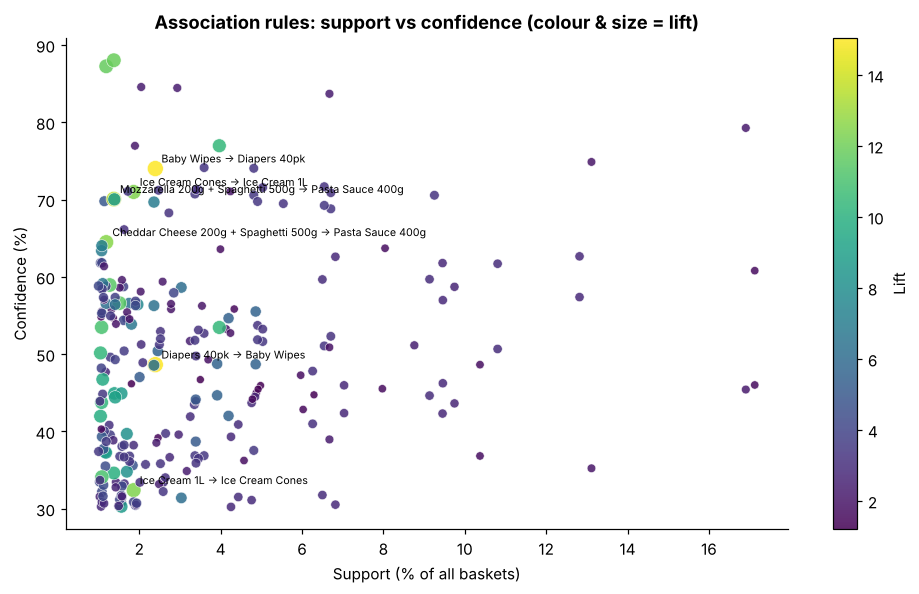

In [11]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sc = ax.scatter(strong.support * 100, strong.confidence * 100, c=strong.lift, cmap="viridis",
                s=20 + strong.lift * 6, alpha=.85, edgecolor="white", linewidth=.4)
plt.colorbar(sc, label="Lift")
ax.set(xlabel="Support (% of all baskets)", ylabel="Confidence (%)",
       title="Association rules: support vs confidence (colour & size = lift)")
for _, r in strong.nlargest(6, "lift").iterrows():
    ax.annotate(r.rule.replace("  ->  ", " → "), (r.support * 100, r.confidence * 100),
                fontsize=7, xytext=(4, 4), textcoords="offset points")
fig.tight_layout(); fig.savefig(OUT / "02_rules_scatter.png", dpi=150); plt.show()

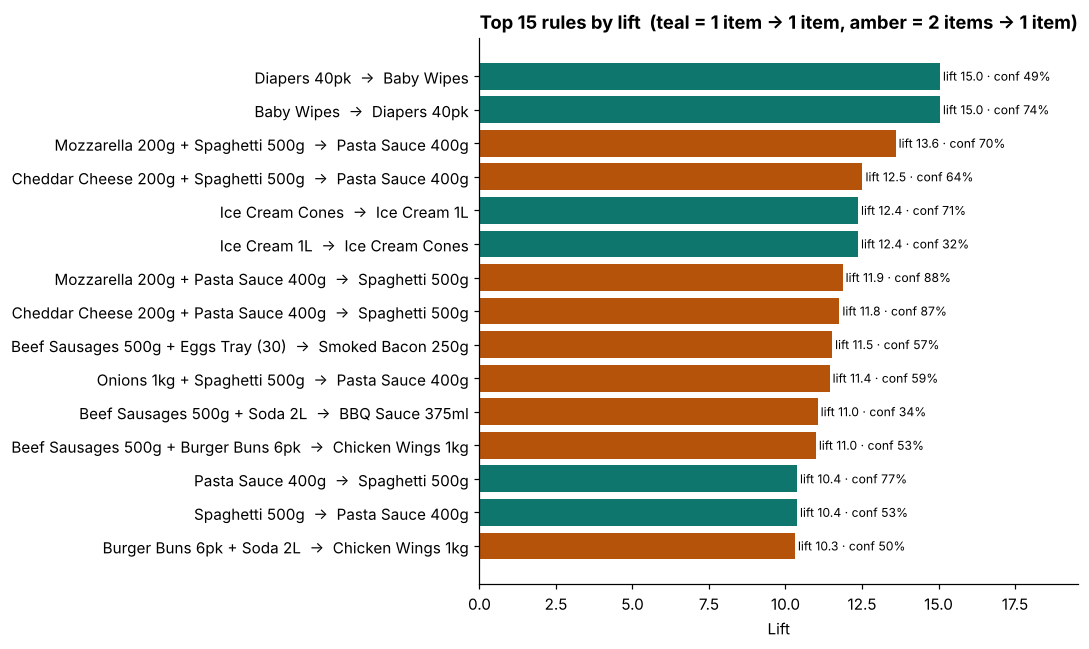

In [12]:
top = strong.nlargest(15, "lift").iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top.rule.str.replace("  ->  ", "  →  "), top.lift,
        color=[TEAL if k == 1 else AMBER for k in top.n_antecedent])
for y, (l, c) in enumerate(zip(top.lift, top.confidence)):
    ax.text(l + .1, y, f"lift {l:.1f} · conf {c:.0%}", va="center", fontsize=8)
ax.set(xlabel="Lift", title="Top 15 rules by lift  (teal = 1 item → 1 item, amber = 2 items → 1 item)")
ax.set_xlim(0, top.lift.max() * 1.3)
fig.tight_layout(); fig.savefig(OUT / "03_top_rules.png", dpi=150); plt.show()

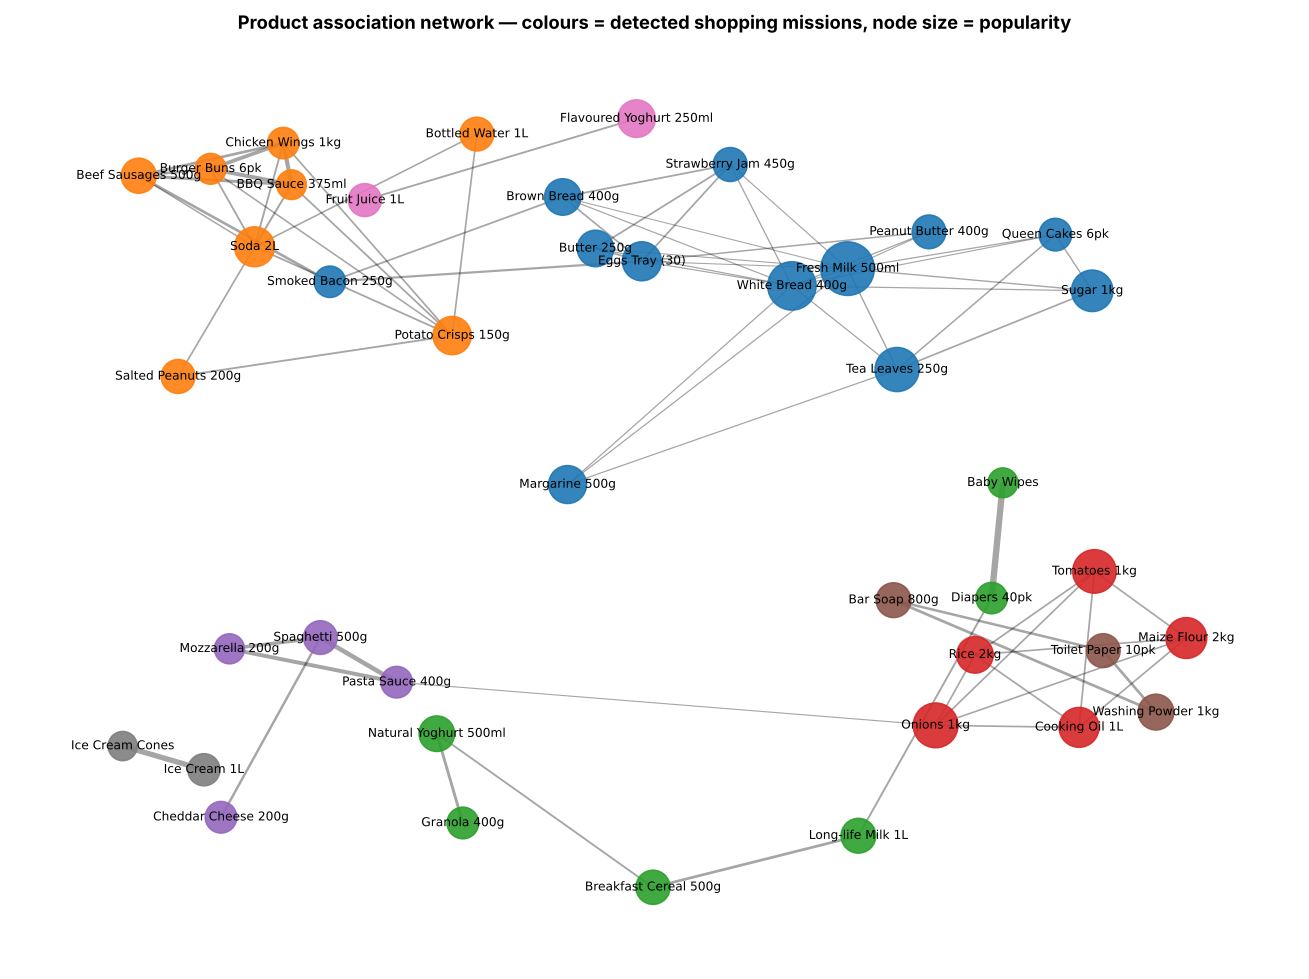

Mission cluster 1: Brown Bread 400g, Butter 250g, Eggs Tray (30), Fresh Milk 500ml, Margarine 500g, Peanut Butter 400g, Queen Cakes 6pk, Smoked Bacon 250g, Strawberry Jam 450g, Sugar 1kg, Tea Leaves 250g, White Bread 400g
Mission cluster 2: BBQ Sauce 375ml, Beef Sausages 500g, Bottled Water 1L, Burger Buns 6pk, Chicken Wings 1kg, Potato Crisps 150g, Salted Peanuts 200g, Soda 2L
Mission cluster 3: Baby Wipes, Breakfast Cereal 500g, Diapers 40pk, Granola 400g, Long-life Milk 1L, Natural Yoghurt 500ml
Mission cluster 4: Cooking Oil 1L, Maize Flour 2kg, Onions 1kg, Rice 2kg, Tomatoes 1kg
Mission cluster 5: Cheddar Cheese 200g, Mozzarella 200g, Pasta Sauce 400g, Spaghetti 500g
Mission cluster 6: Bar Soap 800g, Toilet Paper 10pk, Washing Powder 1kg
Mission cluster 7: Flavoured Yoghurt 250ml, Fruit Juice 1L
Mission cluster 8: Ice Cream 1L, Ice Cream Cones


In [13]:
pairs = strong[strong.n_antecedent == 1].copy()
pairs["a"] = pairs.antecedents.map(lambda s: next(iter(s)))
pairs["b"] = pairs.consequents.map(lambda s: next(iter(s)))
G = nx.Graph()
for _, r in pairs.iterrows():
    if G.has_edge(r.a, r.b):
        G[r.a][r.b]["lift"] = max(G[r.a][r.b]["lift"], r.lift)
    else:
        G.add_edge(r.a, r.b, lift=r.lift)
communities = nx.algorithms.community.greedy_modularity_communities(G, weight="lift")
palette = plt.cm.tab10.colors
node_colour = {n_: palette[i % 10] for i, c in enumerate(communities) for n_ in c}

fig, ax = plt.subplots(figsize=(12, 9))
pos = nx.spring_layout(G, k=.9, seed=7, weight="lift")
nx.draw_networkx_edges(G, pos, width=[.4 + G[u][v]["lift"] / 4 for u, v in G.edges()], alpha=.35, ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=[node_colour[n_] for n_ in G.nodes()],
                       node_size=[300 + 2500 * X[n_].mean() for n_ in G.nodes()], alpha=.9, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
ax.set_title("Product association network — colours = detected shopping missions, node size = popularity")
ax.axis("off"); fig.tight_layout(); fig.savefig(OUT / "04_product_network.png", dpi=150); plt.show()

for i, c in enumerate(communities, 1):
    print(f"Mission cluster {i}: {', '.join(sorted(c))}")

**Interpretation of the network:** with no labels given, the community-detection algorithm **finds the shopping missions on its own**. It recovers **8 clusters**: *tea-time & breakfast* (tea, sugar, milk, breads, spreads, plus the fry-up items eggs and bacon, which are bought alongside bread and butter), *BBQ / party & snacks*, *dinner cook* (maize flour, rice, oil, tomatoes, onions), *pasta night* (spaghetti, sauce, cheddar, mozzarella), *cleaning*, *kids' lunch* (flavoured yoghurt + juice), *dessert* (ice cream + cones), and a *cereal / yoghurt / baby* cluster held together by long-life milk. Where missions overlap (fry-up inside breakfast, baby linked to cereal through long-life milk), the algorithm merges them. That's a useful reminder that the clusters need a human to name and sanity-check them. This is one of the most useful results of MBA. It shows how customers actually shop, which may differ from how the store is organised (by supplier or category).

## 12. Segment comparison — supermarket vs duka shoppers

One set of rules for every store can hide real differences. We re-run the mining separately per channel and compare the lift of the same rules.

In [14]:
def mine(mask, min_support=MIN_SUPPORT):
    fi = fpgrowth(X[mask], min_support=min_support, use_colnames=True)
    r = association_rules(fi, metric="lift", min_threshold=1.0)
    r = r[(r.antecedents.map(len) == 1) & (r.consequents.map(len) == 1)]
    r["rule"] = r.antecedents.map(fmt) + "  ->  " + r.consequents.map(fmt)
    return r.set_index("rule")[["support", "confidence", "lift"]]

store = basket.store_type.reindex(X.index)
seg = mine(store == "Supermarket").join(mine(store == "Duka"), lsuffix="_super", rsuffix="_duka", how="outer")
seg["supermarket_only"] = seg.lift_duka.isna()
print(f"Pair rules: supermarket {seg.lift_super.notna().sum()}, duka {seg.lift_duka.notna().sum()}, "
      f"found only in supermarkets: {seg.supermarket_only.sum()}")
seg.to_csv(OUT / "segment_rules.csv")
(seg.dropna().assign(lift_gap=lambda d: d.lift_super - d.lift_duka)
    .sort_values("confidence_duka", ascending=False)
    .head(8)[["support_super", "confidence_super", "lift_super", "support_duka", "confidence_duka", "lift_duka"]]
    .round(3))

Pair rules: supermarket 236, duka 142, found only in supermarkets: 96


,support_super,confidence_super,lift_super,support_duka,confidence_duka,lift_duka
rule,,,,,,
Tea Leaves 250g -> Fresh Milk 500ml,0.133,0.750,2.103,0.224,0.835,2.112
Sugar 1kg -> Fresh Milk 500ml,0.108,0.694,1.944,0.165,0.812,2.055
Queen Cakes 6pk -> Fresh Milk 500ml,0.034,0.553,1.550,0.049,0.755,1.909
Baby Wipes -> Diapers 40pk,0.032,0.743,11.144,0.012,0.730,31.886
Margarine 500g -> Fresh Milk 500ml,0.075,0.588,1.649,0.088,0.713,1.804
Sugar 1kg -> Tea Leaves 250g,0.086,0.548,3.095,0.142,0.697,2.601
White Bread 400g -> Fresh Milk 500ml,0.165,0.557,1.561,0.180,0.696,1.761
Tomatoes 1kg -> Onions 1kg,0.130,0.598,2.477,0.126,0.677,3.450


**Interpretation:**

* **Dukas** produce fewer pair rules (about 140 vs about 240) because baskets are smaller (median 3 items vs 5), and around 100 rules appear **only** in supermarkets. The duka rules with the highest confidence are the **tea-time mission** (tea → milk, sugar → milk, sugar → tea), and their confidence is *higher* than in supermarkets. For a duka, this is a clear stocking rule: **never run out of milk, sugar or tea together**. A gap in one loses the sale of the others. This links directly to short-supply monitoring in field-force tools like MerchTrack.
* **Supermarkets** carry the rich, high-value missions: pasta night, BBQ, fry-up, dessert, baby. These are where cross-category displays, bundles and app recommendations pay off.
* So the **route-to-market** response differs by channel: availability and range discipline for dukas, cross-merchandising and promotions for supermarkets.

## 13. From rules to decisions

### 13a. A simple "frequently bought together" recommender

Given what's already in a basket, find every rule whose antecedent is fully contained in the basket and whose consequent is *not* in it yet, then rank the candidates by confidence × lift. This is the logic behind "customers also bought" widgets and POS prompts.

In [15]:
def recommend(basket_items, rules_df=strong, k=3):
    basket_items = set(basket_items)
    cand = rules_df[rules_df.antecedents.map(lambda a: a <= basket_items)
                    & ~rules_df.consequents.map(lambda c: c <= basket_items)].copy()
    if cand.empty:
        return pd.DataFrame(columns=["recommend", "because_basket_has", "confidence", "lift"])
    cand["score"] = cand.confidence * cand.lift
    cand["recommend"] = cand.consequents.map(fmt)
    cand["because_basket_has"] = cand.antecedents.map(fmt)
    return (cand.sort_values("score", ascending=False).drop_duplicates("recommend")
                .head(k)[["recommend", "because_basket_has", "confidence", "lift"]].round(2))

for b in [{"Spaghetti 500g", "Onions 1kg"}, {"Tea Leaves 250g"}, {"Beef Sausages 500g", "Soda 2L"},
          {"Diapers 40pk"}]:
    print(f"\nBasket: {sorted(b)}")
    print(recommend(b).to_string(index=False))


Basket: ['Onions 1kg', 'Spaghetti 500g']
       recommend          because_basket_has  confidence  lift
Pasta Sauce 400g Onions 1kg + Spaghetti 500g        0.59 11.44
    Tomatoes 1kg                  Onions 1kg        0.57  2.80
  Cooking Oil 1L                  Onions 1kg        0.42  2.77

Basket: ['Tea Leaves 250g']
       recommend because_basket_has  confidence  lift
Fresh Milk 500ml    Tea Leaves 250g        0.79  2.13
       Sugar 1kg    Tea Leaves 250g        0.51  2.89
White Bread 400g    Tea Leaves 250g        0.49  1.73

Basket: ['Beef Sausages 500g', 'Soda 2L']
        recommend           because_basket_has  confidence  lift
Chicken Wings 1kg Beef Sausages 500g + Soda 2L        0.44  9.13
  BBQ Sauce 375ml Beef Sausages 500g + Soda 2L        0.34 11.05
  Burger Buns 6pk Beef Sausages 500g + Soda 2L        0.37  8.73

Basket: ['Diapers 40pk']
        recommend because_basket_has  confidence  lift
       Baby Wipes       Diapers 40pk        0.49 15.04
Long-life Milk 1L     

**Interpretation:** the recommender gives sensible suggestions: a pasta basket gets sauce and cheese, a tea basket gets sugar and milk, a BBQ basket gets BBQ sauce, buns and wings. In production you'd add **business rules** on top (stock availability, margin, no recommending items on promotion) and **A/B test** the widget against a control group.

### 13b. Size the cross-sell opportunity

For each rule A → B, the **gap** is the set of baskets that contain A but **not** B. If a prompt, display or bundle converted even a small share of those gap baskets, how much extra revenue would that bring? We assume a conservative **5% conversion** of the gap. This is an illustrative planning assumption that a real A/B test would replace.

In [16]:
price = tx.groupby("product").unit_price_kes.first()
CONVERSION = 0.05
opp = strong[strong.n_antecedent == 1].copy()
opp["A"] = opp.antecedents.map(fmt); opp["B"] = opp.consequents.map(fmt)
opp["gap_baskets"] = [int((X[a] & ~X[b]).sum()) for a, b in zip(opp.A, opp.B)]
opp["price_B_kes"] = opp.B.map(price)
opp["extra_revenue_kes_6m"] = (opp.gap_baskets * CONVERSION * opp.price_B_kes).round(0)
opp = opp.sort_values("extra_revenue_kes_6m", ascending=False)
opp[["A", "B", "confidence", "lift", "gap_baskets", "price_B_kes", "extra_revenue_kes_6m"]].head(10).round(2)

,A,B,confidence,lift,gap_baskets,price_B_kes,extra_revenue_kes_6m
315,Onions 1kg,Rice 2kg,0.31,2.80,2328,380,44232.0
317,Tomatoes 1kg,Rice 2kg,0.32,2.92,2094,380,39786.0
1029,Fresh Milk 500ml,Sugar 1kg,0.35,2.01,3616,190,34352.0
651,Onions 1kg,Cooking Oil 1L,0.42,2.77,1933,340,32861.0
304,Natural Yoghurt 500ml,Granola 400g,0.31,6.07,994,610,30317.0
321,Cooking Oil 1L,Rice 2kg,0.31,2.86,1581,380,30039.0
653,Tomatoes 1kg,Cooking Oil 1L,0.45,2.92,1699,340,28883.0
963,Eggs Tray (30),Butter 250g,0.32,2.91,1445,390,28178.0
655,Maize Flour 2kg,Cooking Oil 1L,0.42,2.77,1435,340,24395.0
1253,Fresh Milk 500ml,Tea Leaves 250g,0.45,2.13,3047,160,24376.0


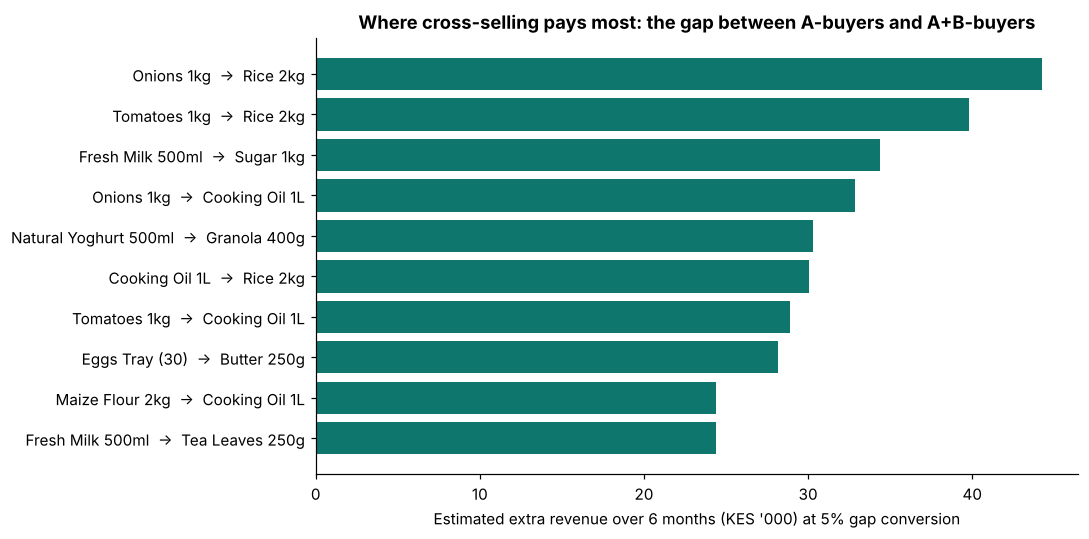

In [17]:
top_opp = opp.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_opp.A + "  →  " + top_opp.B, top_opp.extra_revenue_kes_6m / 1000, color=TEAL)
ax.set(xlabel="Estimated extra revenue over 6 months (KES '000) at 5% gap conversion",
       title="Where cross-selling pays most: the gap between A-buyers and A+B-buyers")
fig.tight_layout(); fig.savefig(OUT / "05_cross_sell_opportunity.png", dpi=150); plt.show()
opp.to_csv(OUT / "cross_sell_opportunity.csv", index=False,
           columns=["A", "B", "support", "confidence", "lift", "gap_baskets", "price_B_kes", "extra_revenue_kes_6m"])

**Interpretation:** the best revenue opportunities are **not the same as the highest-lift rules.** A rule like *Diapers → Wipes* has huge lift but involves few baskets. A rule with moderate lift on a **popular, higher-priced** product can be worth more. This is why rules should always be ranked by **business value** (gap size × price × margin), not by a statistical metric alone.

## 14. Summary of findings and recommended actions

| Finding | Evidence | Recommended action |
|---|---|---|
| The **tea-time mission** (tea + sugar + milk) dominates, especially in dukas | Highest-support pairs; highest duka confidence | Treat the three as one **availability unit**: joint replenishment and short-supply alerts in field tools |
| **Pasta night** (spaghetti + sauce + cheese) is a strong meal solution | Lift 10–13 | Recipe-led secondary display; cheese × pasta co-promotion with partner brands |
| **Ice cream → cones** is one-directional | Confidence of cones → ice cream far higher than the reverse | Put cones *at* the freezer; prompt cones when ice cream is scanned or added online |
| **BBQ / party** and **fry-up** missions exist | Network clusters; multi-item rules | Weekend bundles ("BBQ pack"); deli counter cross-merchandising |
| **Diapers ↔ wipes** is the tightest pair | Highest lift | Adjacent shelving; a bundle price is low-risk since the pair is already bought together |
| Channels behave differently | Segment comparison | Dukas: range and availability discipline. Supermarkets: cross-category displays and app recommendations |

## 15. Where market basket analysis is used

* **Retail & FMCG:** shelf adjacency and planograms, promotion design (and spotting promotions that only cannibalise), bundle pricing, store layout, range rationalisation (keep low sellers that pull in high-value baskets)
* **E-commerce:** "frequently bought together", cart-page cross-sells, personalised email offers
* **Route-to-market / distribution:** joint stocking rules for small outlets, van-sales suggested orders, out-of-stock impact
* **Banking & insurance:** product holding patterns (current account → credit card → insurance) for next-best-offer models
* **Telecoms:** bundle design (data + voice + M-Pesa services)
* **Healthcare:** co-occurring diagnoses, drug co-prescription and adverse-interaction screening
* **Restaurants / QSR:** combo meal design and upsell prompts
* **Manufacturing & maintenance:** parts that fail or get replaced together, for spares kitting

## 16. Limitations and next steps

* **Association ≠ causation.** A rule shows co-occurrence, not that A *causes* B purchases. Validate any action with an A/B or test-vs-control store trial.
* **Ignores quantity, price and time.** Extensions: *sequential pattern mining* (what is bought *next visit*), *utility-weighted* itemset mining (weighted by margin), and seasonality splits.
* **Rare but valuable items** can fall below `min_support`. Mining high-value categories separately, or using multiple minimum supports, solves this.
* **Next steps on real data:** join loyalty IDs for customer-level (not basket-level) patterns, use margin rather than price for opportunity sizing, and track rule stability month by month.